In [1]:
import pandas as pd
import numpy as np
import mne
import os

In [4]:
eeg_df = pd.read_csv("offline_2back_active.csv")
full_eeg_df = pd.read_csv("offline_2back_active.csv")
full_eeg_df.drop(['Time', ' Ch08'], axis = 1, inplace = True)
full_eeg_df

,Ch01,Ch02,Ch03,Ch04,Ch05,Ch06,Ch07
0,37356.855469,4304.361816,-12081.099609,55824.781250,12688.781250,35765.335938,44322.355469
1,37202.957031,4088.425781,-12049.771484,55723.980469,12596.273438,35702.992188,44172.292969
2,36667.425781,4296.064941,-10897.184570,55719.355469,12492.325195,35182.929688,44320.843750
3,36776.667969,4521.608398,-10907.435547,55782.730469,12561.656250,35204.312500,44452.312500
4,37258.867188,4350.471680,-11909.176758,55780.199219,12667.083984,35668.062500,44320.843750
...,...,...,...,...,...,...,...
93540,38285.832031,6078.577148,-9492.921875,51052.312500,14522.671875,37070.300781,45966.324219
93541,37745.835938,6282.664062,-8242.512695,51018.718750,14396.215820,36561.230469,46138.429688
93542,37685.875000,6644.320312,-7787.943848,51080.613281,14445.401367,36391.261719,46392.925781
93543,38178.898438,6484.246094,-8878.445312,51116.832031,14568.615234,36857.988281,46252.355469


In [5]:
markers = pd.read_csv("lifu_markers_1_2back_active.csv")
lifu_on = markers[markers["marker"]=="LIFU_ON"].copy()
lifu_on_time_onset = np.array(lifu_on['Time'])
lifu_on_time_onset

array([131.819562, 358.441138])

In [6]:
lifu_on_time_onset[0]

131.81956199998967

Creating RawArray with float64 data, n_channels=7, n_times=93545
    Range : 0 ... 93544 =      0.000 ...   374.176 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 825 samples (3.300 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenua

C:\Users\jshin\AppData\Local\Temp\ipykernel_23412\3361361688.py:15: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill').fillna(method='ffill')


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Fitting ICA to data using 7 channels (please be patient, this may take a while)
Selecting by explained variance: 6 components
Fitting ICA took 0.6s.


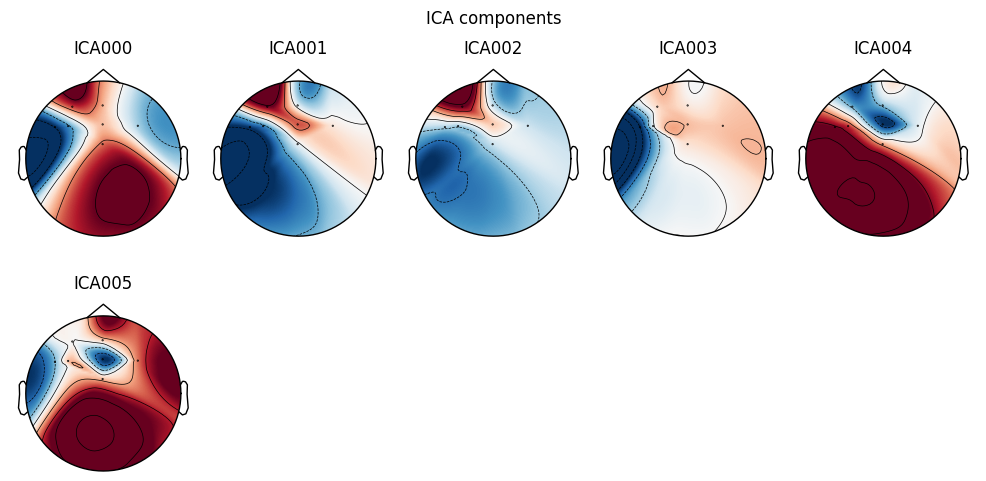

Creating RawArray with float64 data, n_channels=6, n_times=93545
    Range : 0 ... 93544 =      0.000 ...   374.176 secs
Ready.


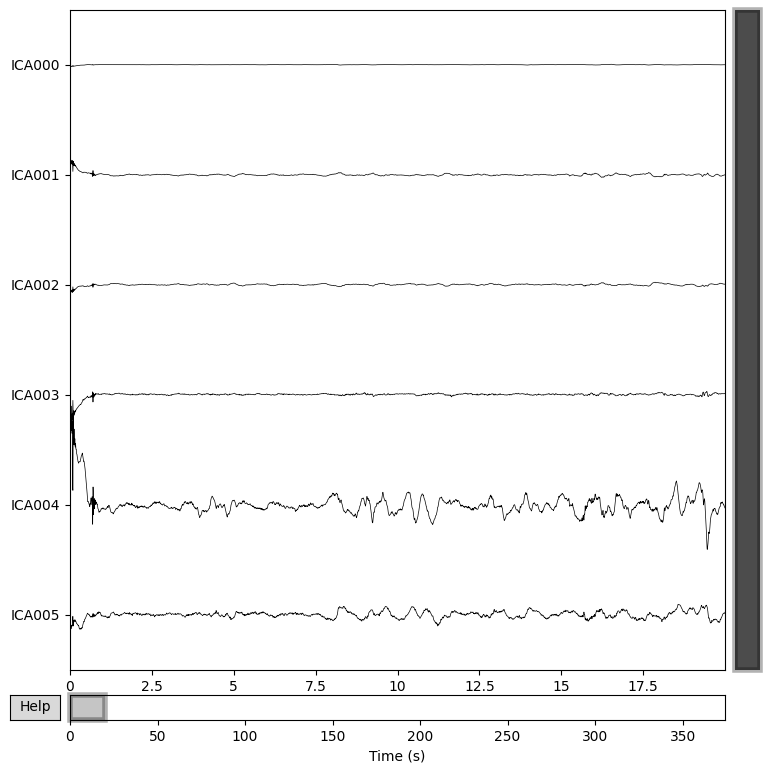

Applying ICA to Raw instance
    Transforming to ICA space (6 components)
    Zeroing out 4 ICA components
    Projecting back using 7 PCA components


In [9]:
import numpy as np
import pandas as pd
import mne
import matplotlib.pyplot as plt

# first_data: rows = samples, columns = 8 EEG channels
# 1. Clean and Load Data

df = pd.DataFrame(full_eeg_df.copy())
df = df.replace([np.inf, -np.inf], np.nan)
df = df.replace(-200000.0, np.nan)
threshold = len(df) * 0.5
df = df.dropna(thresh=threshold, axis=1)
df = df.interpolate(method='linear', limit=5, limit_direction='both')
df = df.fillna(method='bfill').fillna(method='ffill')

# 2. MNE Array Building
sfreq = 250
data = df.values.T  # shape: (n_channels, n_samples)

# Mapping --> make it less manual
ch_names = [
    "Fz",   # 1
    "FC3",   # 2
    "FC5",  # 3
    "F3",   # 4
    "FC4",   # 5
    "FCz",  # 6
    "Cz",  # 7
    #"F5"    # 8
]

info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types='eeg')
raw = mne.io.RawArray(data, info)

# 3. ICA topography
montage = mne.channels.make_standard_montage("standard_1020")
raw.set_montage(montage)

# 4. Filtering
# 1–40 Hz is a good compromise for ICA + PSD
raw.filter(1., 40., fir_design='firwin')
raw.notch_filter(60.)
#raw.filter(l_freq=1.0, h_freq=40.0, method='fir', fir_window='hamming')
raw.set_eeg_reference('average')

# 5. ICA
ica = mne.preprocessing.ICA(
    n_components= 0.99999,
    random_state=97,
    max_iter='auto'
)
ica.fit(raw)

# Inspect components:
ica.plot_components()      # scalp maps
ica.plot_sources(raw)      # time series

# After inspecting, set the components you want to remove:
ica.exclude = [0,1,2,3]  # don't know how to do this
raw_clean = ica.apply(raw.copy())



In [10]:
# lifu_on_time_onset is an array of times in seconds
event_samples = (lifu_on_time_onset * raw.info['sfreq']).astype(int)

# Build MNE event array: shape (n_events, 3)
# Columns: [sample_index, 0, event_id]
events = np.column_stack([event_samples, 
                          np.zeros_like(event_samples, dtype=int), 
                          np.ones_like(event_samples, dtype=int)])
tmin = -2.0
tmax = 7.0

epochs = mne.Epochs(
    raw,
    events,
    event_id=1,
    tmin=tmin,
    tmax=tmax,
    baseline=None,     # or (-2, 0) if you want baseline correction
    preload=True
)


Not setting metadata
2 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 2 events and 2251 original time points ...
0 bad epochs dropped


In [11]:
epochs.get_data().shape # (n_sonications, n_channels, n_times)

(2, 7, 2251)

Number of frequencies: 129
Number of time steps: 36


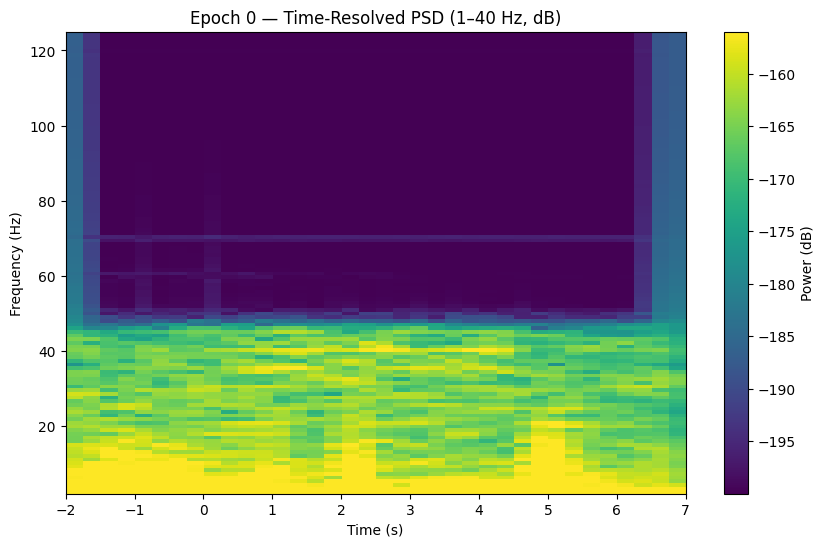

Number of frequencies: 129
Number of time steps: 36


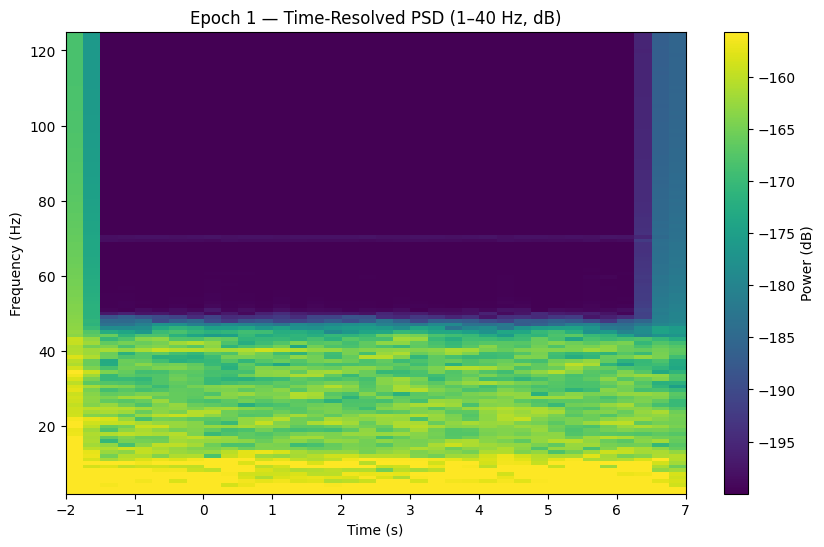

In [50]:
from mne.time_frequency import stft
import numpy as np
import matplotlib.pyplot as plt

sfreq = epochs.info['sfreq']
ch_names = epochs.ch_names

all_spectrograms = []
all_times = []
all_freqs = []

# Loop over epochs
for idx, ep in enumerate(epochs):

    # ep shape: (n_channels, n_times)
    data = ep * 1e-6   # µV → V

    # --- STFT parameters ---
    n_fft = 256
    step = 64

    # --- Compute STFT ---
    Zxx = stft(data, wsize=n_fft, tstep=step)
    power = np.abs(Zxx)**2 / (n_fft**2)

    # --- Build time axis ---
    tmin = epochs.tmin
    tmax = epochs.tmax
    times = np.linspace(tmin, tmax, power.shape[-1])

    # --- Build frequency axis ---
    freqs = np.linspace(0, sfreq/2, power.shape[1])

    # --- Select 1–40 Hz ---
    mask = (freqs >= 1) #& (freqs <= 40)
    freqs_1_40 = freqs[mask]
    power_1_40 = power[:, mask, :]

    # --- Average across channels ---
    psd_avg = power_1_40.mean(axis=0)

    # --- Convert to dB ---
    psd_db = 10 * np.log10(psd_avg + 1e-20)

    # --- Clip color range ---
    vmin = np.percentile(psd_db, 5)
    vmax = np.percentile(psd_db, 95)

    # --- Store results ---
    all_spectrograms.append(psd_db)
    all_times.append(times)
    all_freqs.append(freqs_1_40)

    # --- Plot ---
    plt.figure(figsize=(10,6))
    plt.imshow(
        psd_db,
        aspect='auto',
        origin='lower',
        extent=[times[0], times[-1], freqs_1_40[0], freqs_1_40[-1]],
        vmin=vmin,
        vmax=vmax,
        cmap='viridis'
    )
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")
    plt.title(f"Epoch {idx} — Time‑Resolved PSD (1–40 Hz, dB)")
    plt.colorbar(label="Power (dB)")
    plt.show()


Effective window size : 2.048 (s)
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...


C:\Users\jshin\AppData\Local\Programs\Python\Python310\lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


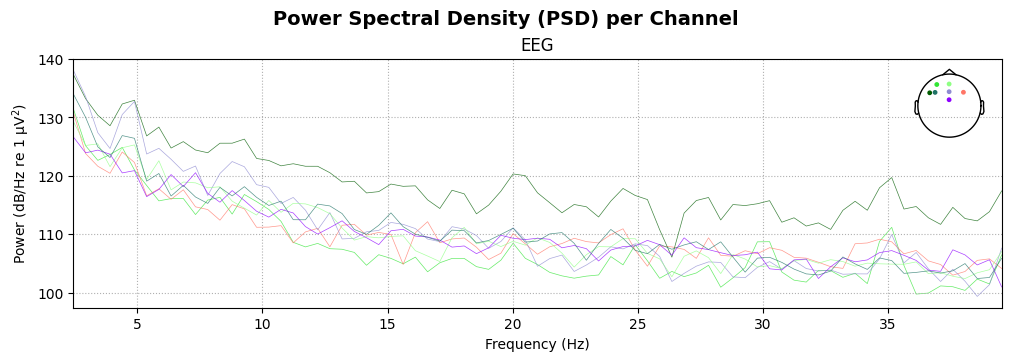

In [13]:
# averages all epochs for PSD

spectrum = epochs.compute_psd(method= "welch",fmin=2, fmax=40, n_fft=512)

# Plot the spectrum across all channels
fig = spectrum.plot(picks='all', spatial_colors=True, exclude='bads')

# Adjust the plot title and layout
fig.suptitle('Power Spectral Density (PSD) per Channel', fontsize=14, weight='bold')
plt.show()


In [23]:
def rebuild_clean_df_and_window(raw_clean, original_df, event_times, pre=2, post=10):
    """
    raw_clean: your preprocessed MNE Raw object (filtered, ICA-cleaned, reref)
    original_df: the original pandas EEG dataframe with the 'Time' column
    event_times: list/array of absolute LSL timestamps (e.g., LIFU onset times)
    pre, post: window lengths in seconds
    """

    data = raw_clean.get_data().T   # shape (n_samples, n_channels)
    sfreq = raw_clean.info['sfreq']
    n_samples = data.shape[0]

    # original_df["Time"].iloc[0] = absolute LSL timestamp of sample 0
    t0 = original_df["Time"].iloc[0]
    time_axis = t0 + np.arange(n_samples) / sfreq

    ch_names = raw_clean.info['ch_names']
    clean_df = pd.DataFrame(data, columns=ch_names)
    clean_df["Time"] = time_axis

    windows = []

    for idx, event in enumerate(event_times):
        mask = (clean_df["Time"] >= (event - pre)) & (clean_df["Time"] <= (event + post))
        window_df = clean_df.loc[mask].copy()

        # Add relative time and index
        window_df["t_rel"] = window_df["Time"] - event
        window_df["idx"] = idx

        windows.append(window_df)

    return clean_df, windows
clean_df, raw_windows = rebuild_clean_df_and_window(
    raw_clean=raw_clean,
    original_df=eeg_df,
    event_times=lifu_on_time_onset,
    pre=2,
    post=10
)

# Example: inspect window 1
raw_windows[0]

,Fz,FC3,FC5,F3,FC4,FCz,Cz,Time,t_rel,idx
32455,12.955830,-16.589227,-34.633959,21.485029,-3.629028,6.160378,14.250976,129.820,-1.999562,0
32456,12.899285,-16.515853,-34.505839,21.423055,-3.658173,6.069948,14.287577,129.824,-1.995562,0
32457,12.810954,-16.733649,-34.386057,21.463960,-3.922951,6.657464,14.110280,129.828,-1.991562,0
32458,12.460943,-16.750516,-33.706876,21.275494,-4.414041,7.130416,14.004580,129.832,-1.987562,0
32459,11.853249,-16.449906,-32.447920,20.811606,-5.049092,7.228307,14.053756,129.836,-1.983562,0
...,...,...,...,...,...,...,...,...,...,...
35450,11.539857,-21.089052,-32.957615,22.558546,-8.538678,17.789447,10.697495,141.800,9.980438,0
35451,12.272756,-21.487911,-34.484734,23.133055,-7.796738,17.750999,10.612573,141.804,9.984438,0
35452,11.890378,-21.368176,-33.709345,22.869922,-8.242115,17.964785,10.594552,141.808,9.988438,0
35453,10.873846,-20.700496,-31.563560,22.025657,-9.195689,17.767164,10.793077,141.812,9.992438,0


In [24]:
base_dir_raw = r"C:\Users\jshin\OW_closedloopLIFU\eeg_windows\raw"
# MAKE SURE TO PUT IN NAME
new_folder_name = "active"
new_folder_path_raw = os.path.join(base_dir_raw, new_folder_name)
os.makedirs(new_folder_path_raw, exist_ok=False) # check

for idx, event in enumerate(raw_windows):
    # Build a unique filename for each event
    output_path_raw = os.path.join(new_folder_path_raw, f"{idx}_eeg_cleaned.csv")
    try:
        raw_windows[idx].to_csv(output_path_raw, index=False, encoding="utf-8")
        print(f"Saved successfully to: {output_path_raw}")
    except (OSError, IOError) as e:
        print(f"Error saving CSV file: {e}")

Saved successfully to: C:\Users\jshin\OW_closedloopLIFU\eeg_windows\raw\active\0_eeg_cleaned.csv
Saved successfully to: C:\Users\jshin\OW_closedloopLIFU\eeg_windows\raw\active\1_eeg_cleaned.csv


In [16]:
epochs.get_data()[0].shape

(7, 2251)

In [31]:
# PSD DATA ANALYSIS
# Part 1: percent change pre and post trigger

fs = 250
prev = 2
posts = 7
pre_window = int(prev*fs)
post_window = int(posts* fs)
eeg_filt = pd.DataFrame(epochs.get_data()[0].copy()).T # CHANGE TO ACTUAL DATA FRAME
#target_timestamp
pre_segments = []
post_segments  = []
pre_segments.append(eeg_filt.iloc[:pre_window])
post_segments.append(eeg_filt.iloc[pre_window:])

In [32]:
from scipy.signal import welch
import numpy as np

def compute_psd(seg):
    f, psd = welch(seg, fs=fs, nperseg=fs, axis=0)
    return f, psd  # psd shape: freqs × channels
pre_psds  = []
post_psds = []

for pre, post in zip(pre_segments, post_segments):
    f, pre_psd  = compute_psd(pre)
    f, post_psd = compute_psd(post)
    pre_psds.append(pre_psd)
    post_psds.append(post_psd)
pre_psd_mean  = np.mean(pre_psds, axis=0)
post_psd_mean = np.mean(post_psds, axis=0)


In [33]:
percent_change_psd = (post_psd_mean - pre_psd_mean) / pre_psd_mean *100
percent_change_psd = pd.DataFrame(percent_change_psd)
percent_change_psd

,0,1,2,3,4,5,6
0,-70.399872,-96.039546,-97.935181,-74.149518,-85.355360,-96.595466,21.729159
1,-92.957058,-97.470323,-97.640884,-92.132503,-90.355827,-98.605252,-92.576511
2,-94.822434,-98.612202,-98.258073,-96.949231,-94.864809,-99.079751,-90.016334
3,-93.859732,-98.250244,-97.403529,-98.404142,-95.519767,-99.439257,-48.348691
4,-97.820382,-98.113419,-96.263071,-93.353413,-94.232940,-99.146085,-76.240169
...,...,...,...,...,...,...,...
121,3.291641,-6.952472,-2.408779,-21.924315,-12.367417,-0.163068,-3.852511
122,-54.415991,-68.602262,-43.796043,-27.701406,-53.748363,-32.038549,31.158492
123,-44.559504,-71.113969,-70.194606,-70.829060,-50.775697,58.662393,0.328671
124,136.512789,-13.425276,674.584485,641.854695,221.066334,139.782902,156.818166


In [34]:
def band_power(psd, freqs, f_lo, f_hi):
    idx = (freqs >= f_lo) & (freqs <= f_hi)
    return np.trapz(psd[idx, :], freqs[idx], axis=0)
# Theta (4–7 Hz)
pre_theta  = band_power(pre_psd_mean,  f, 4, 7)
post_theta = band_power(post_psd_mean, f, 4, 7)

# Alpha (8–12 Hz)
pre_alpha  = band_power(pre_psd_mean,  f, 8, 12)
post_alpha = band_power(post_psd_mean, f, 8, 12)

# Beta (13–30 Hz)
pre_beta  = band_power(pre_psd_mean,  f, 13, 30)
post_beta = band_power(post_psd_mean, f, 13, 30)

# Gamma (30-40Hz)
pre_gamma = band_power(pre_psd_mean,  f, 30, 40)
post_gamma = band_power(post_psd_mean, f, 30, 40)


theta_pct = (post_theta - pre_theta) / pre_theta * 100
alpha_pct = (post_alpha - pre_alpha) / pre_alpha * 100
beta_pct  = (post_beta  - pre_beta ) / pre_beta  * 100
gamma_pct =  (post_gamma  - pre_gamma ) / pre_gamma  * 100

bands_pct_df = pd.DataFrame({
    "Theta %Δ": theta_pct,
    "Alpha %Δ": alpha_pct,
    "Beta %Δ":  beta_pct,
    "Gamma %Δ" : gamma_pct,
})
bands_pct_df.index = [f"Ch{i+1}" for i in range(7)]
bands_pct_df


,Theta %Δ,Alpha %Δ,Beta %Δ,Gamma %Δ
Ch1,-97.203688,-78.664993,-41.963305,7.384488
Ch2,-96.510528,-53.845319,-17.201609,10.490568
Ch3,-93.843888,-35.095527,-10.363827,161.206432
Ch4,-89.420175,-67.890543,0.966328,176.692008
Ch5,-92.353069,7.611887,3.813621,22.193981
Ch6,-98.920159,-91.896032,-68.114128,-9.119752
Ch7,-82.078495,-71.902572,22.922420,-20.850853


In [46]:
event_samples


array([32954, 89610])

In [48]:
ns_array = np.array([175,250]) 
not_sonicating_array = (ns_array * raw.info['sfreq']).astype(int)
not_sonicating_events = np.column_stack([not_sonicating_array, 
                          np.zeros_like(event_samples, dtype=int), 
                          np.ones_like(event_samples, dtype=int)])

epochs_ns = mne.Epochs(
    raw,
    not_sonicating_events,
    event_id=1,
    tmin=tmin,
    tmax=tmax,
    baseline=None,     # or (-2, 0) if you want baseline correction
    preload=True
)


Not setting metadata
2 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 2 events and 2251 original time points ...
0 bad epochs dropped


Number of frequencies: 129
Number of time steps: 36


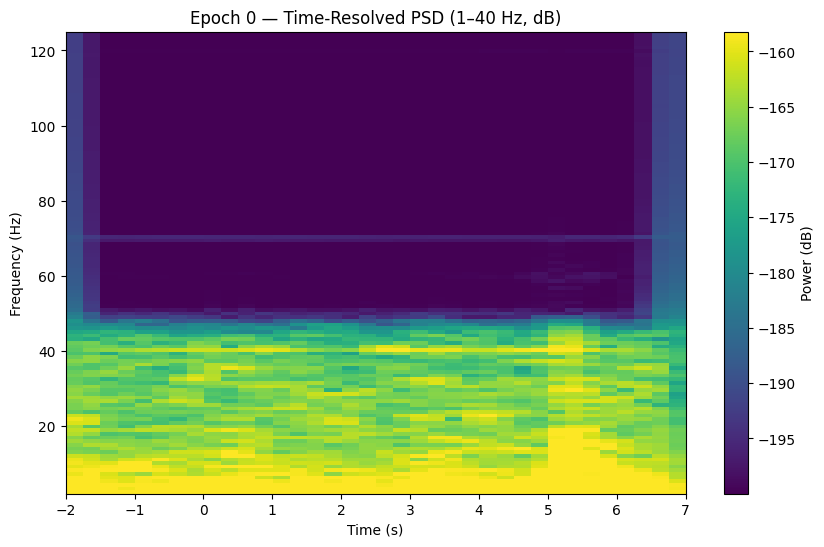

Number of frequencies: 129
Number of time steps: 36


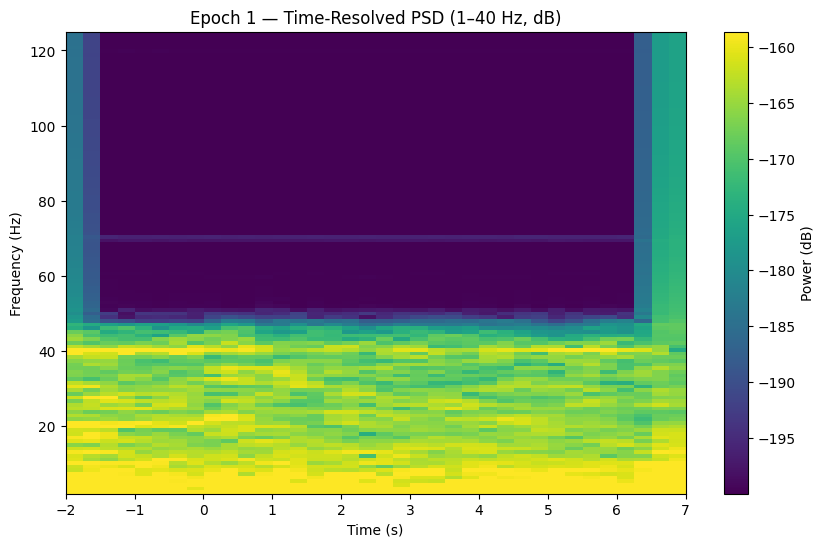

In [51]:
from mne.time_frequency import stft
import numpy as np
import matplotlib.pyplot as plt

sfreq = epochs_ns.info['sfreq']
ch_names = epochs_ns.ch_names

all_spectrograms = []
all_times = []
all_freqs = []

# Loop over epochs
for idx, ep in enumerate(epochs_ns):

    # ep shape: (n_channels, n_times)
    data = ep * 1e-6   # µV → V

    # --- STFT parameters ---
    n_fft = 256
    step = 64

    # --- Compute STFT ---
    Zxx = stft(data, wsize=n_fft, tstep=step)
    power = np.abs(Zxx)**2 / (n_fft**2)

    # --- Build time axis ---
    tmin = epochs.tmin
    tmax = epochs.tmax
    times = np.linspace(tmin, tmax, power.shape[-1])

    # --- Build frequency axis ---
    freqs = np.linspace(0, sfreq/2, power.shape[1])

    # --- Select 1–40 Hz ---
    mask = (freqs >= 1) #& (freqs <= 40)
    freqs_1_40 = freqs[mask]
    power_1_40 = power[:, mask, :]

    # --- Average across channels ---
    psd_avg = power_1_40.mean(axis=0)

    # --- Convert to dB ---
    psd_db = 10 * np.log10(psd_avg + 1e-20)

    # --- Clip color range ---
    vmin = np.percentile(psd_db, 5)
    vmax = np.percentile(psd_db, 95)

    # --- Store results ---
    all_spectrograms.append(psd_db)
    all_times.append(times)
    all_freqs.append(freqs_1_40)

    # --- Plot ---
    plt.figure(figsize=(10,6))
    plt.imshow(
        psd_db,
        aspect='auto',
        origin='lower',
        extent=[times[0], times[-1], freqs_1_40[0], freqs_1_40[-1]],
        vmin=vmin,
        vmax=vmax,
        cmap='viridis'
    )
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")
    plt.title(f"Epoch {idx} — Time‑Resolved PSD (1–40 Hz, dB)")
    plt.colorbar(label="Power (dB)")
    plt.show()
